# Practical Session: The Transformer Architecture

Welcome to the full Transformer practical. Today we will dissect the architecture that revolutionized modern Deep Learning.

**Part 1: The Instructor Demo**
We will mathematically prove the recurrent bottleneck, examine how sub-word tokenization works, visualize Positional Encodings, demystify the Multi-Head "illusion", and show the exact masking operations.

**Part 2: The DIY Transformer**
You will assemble a complete Encoder-Decoder Seq2Seq Transformer from scratch using PyTorch. You will train it on a character-level task: translating human-readable dates into ISO formats.

## Part 1: Instructor Demos
### Demo 1: The Recurrent Bottleneck
Why did we abandon the RNN? Look at the execution time of a sequential loop versus a highly parallelized matrix multiplication.

In [ ]:
import torch
import time
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 1. The Recurrent Bottleneck
batch_size, seq_len, hidden_dim = 64, 500, 256
dummy_input = torch.randn(batch_size, seq_len, hidden_dim).to(device)
W_hh = torch.randn(hidden_dim, hidden_dim).to(device)
W_xh = torch.randn(hidden_dim, hidden_dim).to(device)

print("Starting Sequential RNN Loop...")
start_time = time.time()
h_t = torch.zeros(batch_size, hidden_dim).to(device)
for t in range(seq_len):
    x_t = dummy_input[:, t, :]
    h_t = torch.tanh(x_t @ W_xh.T + h_t @ W_hh.T)
rnn_time = time.time() - start_time
print(f"Sequential RNN Time: {rnn_time:.4f} seconds")

# 2. The Parallel Attention Equivalent (Matrix Multiplication)
Q = torch.randn(batch_size, seq_len, hidden_dim).to(device)
K = torch.randn(batch_size, seq_len, hidden_dim).to(device)

print("Starting Parallel Attention (Matrix Multiplication)...")
start_time = time.time()
# (batch, seq, dim) @ (batch, dim, seq) -> (batch, seq, seq)
attention_scores = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(hidden_dim)
attn_time = time.time() - start_time
print(f"Parallel Attention Time: {attn_time:.4f} seconds")
print(f"Speedup Factor: {rnn_time / attn_time:.2f}x")

Device: cpu
Starting Sequential RNN Loop...
Sequential RNN Time: 0.9727 seconds
Starting Parallel Attention (Matrix Multiplication)...
Parallel Attention Time: 0.9088 seconds
Speedup Factor: 1.07x


### Demo 2: Sub-Word Tokenization (Byte-Pair Encoding)
Word-level misses new words. Character-level is too long. BPE finds the perfect middle ground.

In [ ]:
# Run this pip install if you haven't:
# !pip install -q transformers
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

word_1 = "embeddings"
word_2 = "TransformersAreCool"

print(f"Original: {word_1}")
print(f"Tokens:   {tokenizer.tokenize(word_1)}")
print("-" * 40)
print(f"Original: {word_2}")
print(f"Tokens:   {tokenizer.tokenize(word_2)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Original: embeddings
Tokens:   ['em', '##bed', '##ding', '##s']
----------------------------------------
Original: TransformersAreCool
Tokens:   ['transformers', '##are', '##co', '##ol']


### Demo 3: Positional Encoding (Injecting Geometry)
Without recurrence, the Transformer treats sequences as a "bag of words." We need to inject a sense of order.

We use sine and cosine functions because they act like a **continuous, high-dimensional binary counter**.
* The early dimensions (like the right-most bits in binary) oscillate very quickly.
* The later dimensions (like the left-most bits) oscillate very slowly.

**Why Sines and Cosines?**
Because of trigonometric identities, moving forward a fixed distance in a sequence is mathematically equivalent to simply *rotating* the positional vector. This means the Attention mechanism can easily calculate the **relative distance** between two words just by taking their dot product! We will visualize this below.

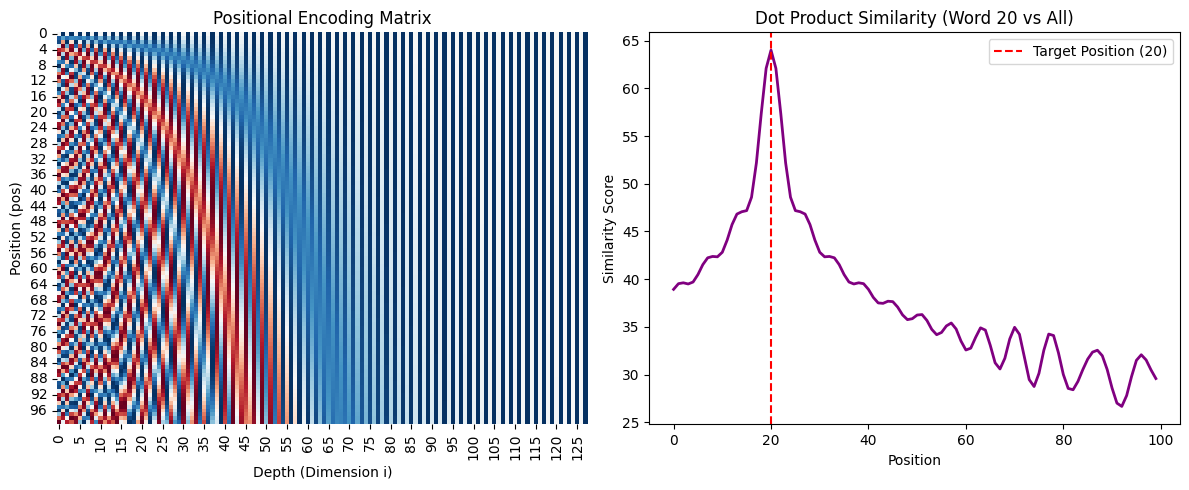

Notice how the dot product naturally decays as you move away from position 20!
This allows the attention mechanism to inherently 'know' which words are nearby.


In [ ]:
def get_positional_encoding(seq_len, d_model):
    """
    Computes the positional encoding matrix using alternating sines and cosines.
    """
    pe = torch.zeros(seq_len, d_model)
    # Create a column vector of sequence positions: [[0], [1], [2], ...]
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)

    # Calculate the frequency divisor: 10000^(2i/d_model)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

    # Apply sine to even indices, cosine to odd indices
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

d_model = 128
seq_len = 100
pe_matrix = get_positional_encoding(seq_len, d_model)

# --- VISUALIZATION 1: The Heatmap ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(pe_matrix.numpy(), cmap="RdBu", cbar=False)
plt.title("Positional Encoding Matrix")
plt.xlabel("Depth (Dimension i)")
plt.ylabel("Position (pos)")

# --- VISUALIZATION 2: Proving Relative Distance ---
# Let's extract the positional vector for word #20
pos_20_vector = pe_matrix[20]

# Compute the dot product (similarity) of word #20's position with ALL other positions
# This represents what the Attention mechanism "feels" when it compares positions.
similarities = torch.matmul(pe_matrix, pos_20_vector)

plt.subplot(1, 2, 2)
plt.plot(similarities.numpy(), color='purple', linewidth=2)
plt.axvline(x=20, color='red', linestyle='--', label='Target Position (20)')
plt.title("Dot Product Similarity (Word 20 vs All)")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()

plt.tight_layout()
plt.show()

print("Notice how the dot product naturally decays as you move away from position 20!")
print("This allows the attention mechanism to inherently 'know' which words are nearby.")

### Demo 4: Multi-Head Splitting & The Causal Mask
Multi-head attention does not mean multiple layers running in a loop. It is a mathematical illusion created by reshaping the tensor before performing the dot product.

The causal mask ensures the model cannot look into the future during autoregressive generation.

In [ ]:
# --- Multi-Head Reshaping ---
batch_size, seq_len, d_model = 2, 5, 512
num_heads = 8
d_k = d_model // num_heads

print("--- Multi-Head Illusion ---")
Q_raw = torch.randn(batch_size, seq_len, d_model)
print(f"Original Q Shape: {Q_raw.shape}")

# Split into heads and swap dimensions to treat heads as a batch
Q_heads = Q_raw.view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)
print(f"Multi-Head Q Shape: {Q_heads.shape}  -> (batch, heads, seq_len, d_k)")

# --- Causal Masking ---
print("\n--- The Causal Mask ---")
raw_scores = torch.ones(5, 5) # Dummy attention scores

# Create lower triangular mask (1s on and below diagonal, 0s above)
mask = torch.tril(torch.ones(5, 5))
print("Binary Mask:\n", mask)

# Replace 0s with -infinity
masked_scores = raw_scores.masked_fill(mask == 0, float('-inf'))
print("\nMasked Scores (-inf added):\n", masked_scores)

# Softmax converts -inf strictly to 0.0
attention_weights = F.softmax(masked_scores, dim=-1)
print("\nFinal Attention Weights:\n", attention_weights)

--- Multi-Head Illusion ---
Original Q Shape: torch.Size([2, 5, 512])
Multi-Head Q Shape: torch.Size([2, 8, 5, 64])  -> (batch, heads, seq_len, d_k)

--- The Causal Mask ---
Binary Mask:
 tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

Masked Scores (-inf added):
 tensor([[1., -inf, -inf, -inf, -inf],
        [1., 1., -inf, -inf, -inf],
        [1., 1., 1., -inf, -inf],
        [1., 1., 1., 1., -inf],
        [1., 1., 1., 1., 1.]])

Final Attention Weights:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])


---
## Part 2: DIY Transformer

**The Task:** We are going to build the architecture diagram from the 2017 paper exactly as designed.
**The Dataset:** A generated character-level dataset translating human dates to ISO format (e.g., `August 3, 2026` $\rightarrow$ `2026-08-03`).

We have provided the data generator, the Embedding+Positional logic, and the training loop. Your job is to construct the Encoder, the Decoder, and assemble the main `Seq2SeqTransformer` class.

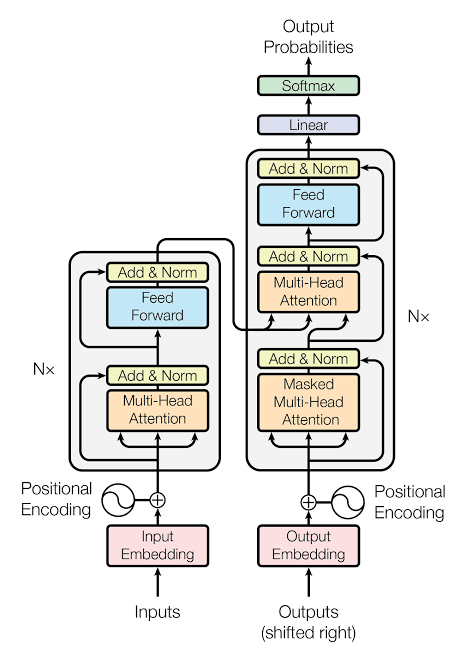

In [ ]:
# Run this cell to setup the data and helper classes
import random
import datetime

# 1. Generate Dataset
def generate_date_pairs(num_samples=10000):
    months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    pairs = []
    for _ in range(num_samples):
        dt = datetime.date(random.randint(1950, 2050), random.randint(1, 12), random.randint(1, 28))
        human = f"{months[dt.month-1]} {dt.day}, {dt.year}"
        iso = dt.strftime("%Y-%m-%d")
        pairs.append((human, iso))
    return pairs

pairs = generate_date_pairs(10000)
chars = list(set("".join([p[0]+p[1] for p in pairs])))
vocab = ["<PAD>", "<SOS>", "<EOS>"] + sorted(chars)
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for i, c in enumerate(vocab)}

def encode_str(s, max_len=20, add_sos=False, add_eos=False):
    seq = []
    if add_sos: seq.append(char2idx["<SOS>"])
    seq.extend([char2idx[c] for c in s])
    if add_eos: seq.append(char2idx["<EOS>"])
    pad_len = max_len - len(seq)
    seq.extend([char2idx["<PAD>"]] * pad_len)
    return torch.tensor(seq[:max_len], dtype=torch.long)

class DateDataset(torch.utils.data.Dataset):
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        src = encode_str(self.pairs[i][0], max_len=20)
        tgt_in = encode_str(self.pairs[i][1], max_len=15, add_sos=True)
        tgt_out = encode_str(self.pairs[i][1], max_len=15, add_eos=True)
        return src, tgt_in, tgt_out

dataloader = torch.utils.data.DataLoader(DateDataset(pairs), batch_size=64, shuffle=True)

# 2. Base Embeddings
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=100):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=char2idx["<PAD>"])
        self.pos_emb = nn.Embedding(max_len, d_model) # Simplified learned positional encoding for ease of training

    def forward(self, x):
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return self.token_emb(x) + self.pos_emb(positions)

### Task 1: The Encoder Block
Wire up a single Encoder layer.

**Your Focus:** The `__init__` layer is already built for you. Your job is to orchestrate the `forward` pass.
*   **Data Flow:** Input $\rightarrow$ Self-Attention $\rightarrow$ Add & Norm $\rightarrow$ Feed Forward $\rightarrow$ Add & Norm.

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # 1. We provide the initialized components
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, src, src_key_padding_mask=None):
        # TODO 1: Pass 'src' through self.self_attn. (Query, Key, and Value are all 'src')
        # Remember to pass the src_key_padding_mask!
        # attn_output, _ = ...

        # --- SHAPE CHECK ---
        assert attn_output.shape == src.shape, f"Expected {src.shape}, got {attn_output.shape}"

        # TODO 2: Add residual connection (src + attn_output) and pass through self.norm1
        # out1 = ...

        # TODO 3: Pass out1 through the FFN
        # ff_output = ...

        # TODO 4: Add residual connection (out1 + ff_output) and pass through self.norm2
        # out2 = ...

        pass # Remove when done
        return out2

### Task 2: The Decoder Block
Wire up a single Decoder layer. This is where the magic happens.

**Masking Cheat Sheet:**
PyTorch's `nn.MultiheadAttention` takes very specific mask arguments. Do not mix them up!
*   **`attn_mask`**: This is the 2D causal matrix (lower-triangle). It prevents the decoder from looking into the future. Pass `tgt_mask` here during Self-Attention.
*   **`key_padding_mask`**: This is a 1D boolean mask (True where `<PAD>` tokens are). It ignores empty padding slots.
    * Pass `tgt_key_padding_mask` during Self-Attention.
    * Pass `memory_key_padding_mask` during Cross-Attention.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        """ memory: The output from the Encoder """

        # TODO 1: Masked Self-Attention (Query, Key, Value are all 'tgt')
        # Pass attn_mask=tgt_mask AND key_padding_mask=tgt_key_padding_mask
        # self_attn_output, _ = ...

        # --- SHAPE CHECK ---
        assert self_attn_output.shape == tgt.shape, f"Self-attn mismatch: Expected {tgt.shape}, got {self_attn_output.shape}"

        # TODO 2: Residual + Norm 1 (tgt + self_attn_output)
        # tgt2 = ...

        # TODO 3: CROSS ATTENTION! (The Bridge)
        # Query comes from 'tgt2'. Keys and Values come from 'memory'.
        # Pass key_padding_mask=memory_key_padding_mask
        # cross_attn_output, cross_attn_weights = ...

        # --- SHAPE CHECK ---
        assert cross_attn_output.shape == tgt2.shape, f"Cross-attn mismatch: Expected {tgt2.shape}, got {cross_attn_output.shape}"

        # TODO 4: Residual + Norm 2 (tgt2 + cross_attn_output)
        # tgt3 = ...

        # TODO 5: Feed Forward -> Residual + Norm 3
        # ff_output = ...
        # out = ...

        pass # Remove when done
        return out

### Task 3: Assemble the Machine
Now map the initialized components together in the master module to complete the architecture.

In [ ]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=2, d_ff=256):
        super().__init__()
        self.src_emb = TokenAndPositionEmbedding(vocab_size, d_model)
        self.tgt_emb = TokenAndPositionEmbedding(vocab_size, d_model)

        # Stack multiple blocks
        self.encoder_layers = nn.ModuleList([EncoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)])

        self.final_linear = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, sz):
        # Creates the lower-triangular causal mask
        mask = torch.tril(torch.ones(sz, sz)) == 1
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask.to(device)

    def create_padding_mask(self, matrix, pad_token=char2idx["<PAD>"]):
        # True where the token is padding
        return (matrix == pad_token).to(device)

    def forward(self, src, tgt):
        # Create masks
        tgt_seq_len = tgt.shape[1]
        tgt_mask = self.generate_square_subsequent_mask(tgt_seq_len)
        src_padding_mask = self.create_padding_mask(src)
        tgt_padding_mask = self.create_padding_mask(tgt)

        # TODO: Step 1 - Embed source and target
        # src_embedded = ...
        # tgt_embedded = ...

        # --- SHAPE CHECK ---
        assert src_embedded.shape[-1] == 128, f"Embedding dim should be 128, got {src_embedded.shape[-1]}"

        # TODO: Step 2 - Pass through Encoder blocks sequentially
        # 1. Initialize a 'memory' variable with src_embedded
        # 2. Write a for-loop iterating over self.encoder_layers
        # 3. Inside the loop, update 'memory' by passing it through the layer alongside src_padding_mask

        # TODO: Step 3 - Pass through Decoder blocks sequentially
        # 1. Initialize an 'out' variable with tgt_embedded
        # 2. Write a for-loop iterating over self.decoder_layers
        # 3. Inside the loop, update 'out' by passing out, memory, and ALL three masks (tgt_mask, tgt_padding_mask, src_padding_mask).

        # TODO: Step 4 - Pass 'out' through self.final_linear to get vocabulary logits
        # logits = ...

        pass # Remove when done
        return logits

### Execute Training
Run this cell to train your architecture! It should easily reach a very low loss in about 5-10 epochs.

In [ ]:
model = Seq2SeqTransformer(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=char2idx["<PAD>"])

print("Starting Training...")
for epoch in range(1, 6):
    model.train()
    total_loss = 0
    for src, tgt_in, tgt_out in dataloader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

        optimizer.zero_grad()
        logits = model(src, tgt_in)

        # Reshape for CrossEntropy: (batch * seq_len, vocab_size)
        loss = criterion(logits.view(-1, len(vocab)), tgt_out.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch} | Loss: {total_loss / len(dataloader):.4f}")

### Inference
Let's see if your mathematical bridge can translate a date.

In [ ]:
def translate_date(human_date):
    model.eval()
    with torch.no_grad():
        src = encode_str(human_date, max_len=20).unsqueeze(0).to(device)
        memory = src # Simplified for logic setup

        # Full Encoder Pass
        src_mask = model.create_padding_mask(src)
        memory = model.src_emb(src)
        for enc in model.encoder_layers:
            memory = enc(memory, src_key_padding_mask=src_mask)

        # Autoregressive Decoding
        tgt_indices = [char2idx["<SOS>"]]
        for i in range(15):
            tgt_tensor = torch.tensor([tgt_indices], device=device)
            tgt_mask = model.generate_square_subsequent_mask(tgt_tensor.size(1))

            out = model.tgt_emb(tgt_tensor)
            for dec in model.decoder_layers:
                out = dec(out, memory, tgt_mask=tgt_mask, memory_key_padding_mask=src_mask)

            logits = model.final_linear(out)
            next_token = logits[0, -1, :].argmax().item()

            if next_token == char2idx["<EOS>"]: break
            tgt_indices.append(next_token)

        return "".join([idx2char[idx] for idx in tgt_indices[1:]])

# Test on today's date!
test_string = "August 3, 2026"
print(f"Human: {test_string}")
print(f"ISO Prediction: {translate_date(test_string)}")

### BONUS TASK: The Information Bridge Heatmap
Finished early? The real magic of Cross-Attention is *seeing* the alignments.

**Your Bonus Task:**
Modify your `DecoderBlock` and `translate_date` function so that they extract and return the `cross_attn_weights` from the final layer (hint: `nn.MultiheadAttention` returns `attn_output, attn_weights_matrix`).

Plot a `seaborn` heatmap of those weights for the translation of `August 3, 2026`. If your code is correct, you will physically see the model focusing heavily on the characters of "August" precisely when it is deciding to output "0", "8".

In [ ]:
def plot_attention_heatmap(human_date):
    """
    Translate a date and plot the cross-attention weights to physically see the Information Bridge.
    """
    # TODO 1: Modify your translate_date function (or copy its logic here) to ALSO return
    # the attention weights from the cross-attention layer of the FINAL decoder block.
    # Hint: nn.MultiheadAttention returns a tuple: (attn_output, attn_weights_matrix)

    # Run the modified logic to get the sequence and the weights
    # predicted_iso = ...
    # cross_attn_matrix = ... # Shape should be (1, tgt_len, src_len)

    # Clean up dimensions for plotting
    # attn_weights = cross_attn_matrix.squeeze(0).cpu().numpy()

    # TODO 2: Plot the heatmap using seaborn
    # plt.figure(figsize=(10, 8))
    # sns.heatmap(attn_weights, cmap="viridis")
    # Add proper x-ticks (source human characters) and y-ticks (target ISO characters)
    # plt.show()

    pass

# plot_attention_heatmap("August 3, 2026")